In [ ]:
from google.colab import files
# Ça va ouvrir un bouton pour uploader ton fichier kaggle.json
files.upload()

Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'{"username":"anasseharki","key":"e9ade46dc2e6e031cb7431f85090e572"}'}

In [ ]:
# 1. Configuration du dossier Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 2. Téléchargement du dataset
!kaggle datasets download -d miguelaenlle/massive-stock-news-analysis-db-for-nlpbacktests

# 3. Décompression dans un dossier nommé "stock_news_data"
!unzip -q massive-stock-news-analysis-db-for-nlpbacktests.zip -d stock_news_data

Dataset URL: https://www.kaggle.com/datasets/miguelaenlle/massive-stock-news-analysis-db-for-nlpbacktests
License(s): CC0-1.0
massive-stock-news-analysis-db-for-nlpbacktests.zip: Skipping, found more recently modified local copy (use --force to force download)
replace stock_news_data/analyst_ratings_processed.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace stock_news_data/raw_analyst_ratings.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace stock_news_data/raw_partner_headlines.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y



In [ ]:
import pandas as pd
import os

# On vérifie d'abord les noms exacts des fichiers extraits
print("Fichiers disponibles dans notre dossier :")
print(os.listdir('stock_news_data'))

# On charge l'un des fichiers principaux pour l'inspecter
# (Le fichier 'raw_analyst_ratings.csv' contient généralement beaucoup de titres)
chemin_fichier = 'stock_news_data/raw_analyst_ratings.csv'

# Chargement du fichier CSV
df = pd.read_csv(chemin_fichier)

# Affichage des 5 premières lignes
print("\n--- 5 premières lignes du dataset ---")
display(df.head())

# Affichage des informations (colonnes, types de données, valeurs nulles)
print("\n--- Informations sur le dataset ---")
df.info()

Fichiers disponibles dans notre dossier :
['raw_partner_headlines.csv', 'raw_analyst_ratings.csv', 'analyst_ratings_processed.csv']

--- 5 premières lignes du dataset ---


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A



--- Informations sur le dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Unnamed: 0  1407328 non-null  int64 
 1   headline    1407328 non-null  object
 2   url         1407328 non-null  object
 3   publisher   1407328 non-null  object
 4   date        1407328 non-null  object
 5   stock       1407328 non-null  object
dtypes: int64(1), object(5)
memory usage: 64.4+ MB


In [ ]:
!pip install datasets

In [ ]:
#ce n'est pas sa place skip pour le moment # 1. DÉFINITION DU GROUPE TECH
# Ajoute ici les symboles exacts présents dans ton fichier CSV
big_tech_list = ['GOOGL', 'AAPL', 'MSFT', 'AMZN', 'META']

print(f"Filtrage en cours pour : {big_tech_list}")
df_filtre = df[df['stock'].isin(big_tech_list)].copy()

# 2. NETTOYAGE EXTRÊME
df_filtre = df_filtre.dropna(subset=['headline'])
headlines_list = [str(texte) for texte in df_filtre['headline'].tolist()]
total_articles = len(headlines_list)

print(f"Nombre total d'articles à analyser pour le groupe : {total_articles}")

# 3. ANALYSE FinBERT (Le modèle est déjà chargé en mémoire, ça ira vite)
scores = []
for out in tqdm(finbert(headlines_list, batch_size=64, truncation=True), total=total_articles, desc="Analyse Big Tech"):
    if out['label'] == 'positive':
        scores.append(1.0)
    elif out['label'] == 'negative':
        scores.append(-1.0)
    else:
        scores.append(0.0)

df_filtre['sentiment_finbert'] = scores

# 4. AGRÉGATION PAR JOUR ET PAR ACTION
# Très important : on groupe par 'date' ET 'stock'
df_news_daily = df_filtre.groupby(['date', 'stock'])['sentiment_finbert'].mean().reset_index()

print("\n--- Analyse du groupe Big Tech terminée ! ---")
display(df_news_daily.head(10))

Filtrage en cours pour : ['GOOGL', 'AAPL', 'MSFT', 'AMZN', 'META']


NameError: name 'df' is not defined

In [ ]:
# 1. On ne garde que les colonnes utiles
df = df[['date', 'stock', 'headline']].copy()

# 2. Nettoyage des valeurs nulles
df = df.dropna()

# 3. CORRECTION : On ne garde que les 10 premiers caractères (AAAA-MM-JJ) pour éviter les erreurs de format
df['date'] = df['date'].astype(str).str[:10]

# On convertit ensuite proprement en format Date
df['date'] = pd.to_datetime(df['date']).dt.date

# 4. Afficher le résultat nettoyé
print("--- Dataset nettoyé ---")
display(df.head())

--- Dataset nettoyé ---


,date,stock,headline
0,2020-06-05,A,Stocks That Hit 52-Week Highs On Friday
1,2020-06-03,A,Stocks That Hit 52-Week Highs On Wednesday
2,2020-05-26,A,71 Biggest Movers From Friday
3,2020-05-22,A,46 Stocks Moving In Friday's Mid-Day Session
4,2020-05-22,A,B of A Securities Maintains Neutral on Agilent...


In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# 1. Téléchargement du dictionnaire financier/sentiment de base
nltk.download('vader_lexicon')

# 2. Initialisation de l'analyseur
sia = SentimentIntensityAnalyzer()

# 3. Fonction pour catégoriser le score (compound) en 3 classes
def get_sentiment(text):
    # Le score 'compound' va de -1 (très négatif) à +1 (très positif)
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'Positif'
    elif score <= -0.05:
        return 'Négatif'
    else:
        return 'Neutre'

# 4. Application à notre dataset (ça peut prendre 1 à 2 minutes sur 1,4M de lignes)
print("Analyse des sentiments en cours... Patiente un instant.")
df['sentiment'] = df['headline'].apply(get_sentiment)

# 5. Affichage des résultats et de la distribution
print("\n--- Aperçu des sentiments ---")
display(df.head())

print("\n--- Distribution des classes ---")
print(df['sentiment'].value_counts(normalize=True) * 100) # En pourcentage

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Analyse des sentiments en cours... Patiente un instant.

--- Aperçu des sentiments ---


,date,stock,headline,sentiment
0,2020-06-05,A,Stocks That Hit 52-Week Highs On Friday,Neutre
1,2020-06-03,A,Stocks That Hit 52-Week Highs On Wednesday,Neutre
2,2020-05-26,A,71 Biggest Movers From Friday,Neutre
3,2020-05-22,A,46 Stocks Moving In Friday's Mid-Day Session,Neutre
4,2020-05-22,A,B of A Securities Maintains Neutral on Agilent...,Positif



--- Distribution des classes ---
sentiment
Neutre     52.666756
Positif    31.396945
Négatif    15.936299
Name: proportion, dtype: float64


In [ ]:
# Installation de yfinance si ce n'est pas déjà fait sur Colab
!pip install yfinance -q

import yfinance as yf
import pandas as pd

# 1. Définir notre panier d'actions (Les géants de la Tech)
tech_stocks = ['AAPL', 'MSFT', 'AMZN', 'GOOGL']

# 2. Filtrer le dataset pour ne garder que ces actions
df_tech = df[df['stock'].isin(tech_stocks)].copy()

# 3. Convertir le sentiment en score numérique
def sentiment_to_score(sentiment):
    if sentiment == 'Positif': return 1
    elif sentiment == 'Négatif': return -1
    else: return 0

df_tech['sentiment_score'] = df_tech['sentiment'].apply(sentiment_to_score)

# 4. Agréger les données par Date et par Action (Moyenne du sentiment journalier)
# S'il y a 10 articles sur Apple un jour donné, on aura ainsi le sentiment "moyen" de la journée
df_daily_sentiment = df_tech.groupby(['date', 'stock'])['sentiment_score'].mean().reset_index()

# 5. Télécharger l'historique des prix avec yfinance
print("Téléchargement des données boursières en cours...")
# On récupère les dates min et max de notre dataset pour télécharger la bonne période
start_date = df_daily_sentiment['date'].min()
# On ajoute un jour à la date de fin pour être sûr d'inclure le dernier jour
end_date = df_daily_sentiment['date'].max() + pd.Timedelta(days=1)

stock_data = []
for ticker in tech_stocks:
    print(f"Récupération de {ticker}...")
    # Téléchargement via yfinance
    ticker_data = yf.download(ticker, start=start_date, end=end_date, progress=False)
    ticker_data = ticker_data.reset_index()

    # Formatage de la date pour qu'elle corresponde à notre dataset NLP
    ticker_data['Date'] = pd.to_datetime(ticker_data['Date']).dt.date
    ticker_data['stock'] = ticker

    # On ne garde que les colonnes qui nous intéressent (Date, Ticker, et les Prix)
    # yf.download peut renvoyer un MultiIndex, on s'assure de l'aplatir si nécessaire
    if isinstance(ticker_data.columns, pd.MultiIndex):
        ticker_data.columns = ticker_data.columns.get_level_values(0)

    ticker_data = ticker_data[['Date', 'stock', 'Open', 'Close', 'Volume']]
    ticker_data.rename(columns={'Date': 'date'}, inplace=True)

    stock_data.append(ticker_data)

# Combiner tous les historiques de prix
df_stocks = pd.concat(stock_data, ignore_index=True)

# 6. La fusion finale (Merge) : NLP + Bourse !
df_final = pd.merge(df_daily_sentiment, df_stocks, on=['date', 'stock'], how='inner')

# Calcul de notre variable cible (Target) : Le prix de clôture est-il supérieur au prix d'ouverture ?
# 1 = Hausse (On gagne de l'argent), 0 = Baisse (On en perd)
df_final['Tendance'] = (df_final['Close'] > df_final['Open']).astype(int)

print("\n--- Pipeline de données terminé ! Voici le résultat final ---")
display(df_final.head())
print("\nDimensions du dataset final :", df_final.shape)

y
Téléchargement des données boursières en cours...
Récupération de AAPL...


/tmp/ipykernel_29271/4176583641.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker_data = yf.download(ticker, start=start_date, end=end_date, progress=False)


Récupération de MSFT...


/tmp/ipykernel_29271/4176583641.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker_data = yf.download(ticker, start=start_date, end=end_date, progress=False)


Récupération de AMZN...
Récupération de GOOGL...

--- Pipeline de données terminé ! Voici le résultat final ---


/tmp/ipykernel_29271/4176583641.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker_data = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipykernel_29271/4176583641.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker_data = yf.download(ticker, start=start_date, end=end_date, progress=False)


,date,stock,sentiment_score,Open,Close,Volume,Tendance
0,2018-07-25,GOOGL,0.000000,62.117598,63.274040,51104000,1
1,2018-07-26,GOOGL,0.000000,62.839620,63.748112,54686000,1
2,2018-07-27,GOOGL,0.000000,63.927640,62.130989,48362000,0
3,2018-07-30,GOOGL,-0.333333,61.742200,60.997852,43896000,0
4,2018-07-31,GOOGL,0.600000,61.080668,60.858009,39382000,0



Dimensions du dataset final : (513, 7)


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. Ajout d'une variable financière utile : la variation journalière (en %)
# Cela aide le modèle à comprendre si le marché était très volatil ou calme
df_final['Variation_Prix'] = (df_final['Close'] - df_final['Open']) / df_final['Open']

# 2. Normalisation des données (Très important pour les réseaux de neurones !)
scaler = MinMaxScaler()
df_final[['sentiment_score', 'Variation_Prix']] = scaler.fit_transform(df_final[['sentiment_score', 'Variation_Prix']])

# 3. Fonction pour créer nos fenêtres glissantes de 5 jours
def create_sequences(df, window_size=5):
    X = []
    y = []

    # On traite chaque action (Apple, Google...) séparément pour ne pas mélanger leurs historiques
    for stock in df['stock'].unique():
        stock_data = df[df['stock'] == stock].sort_values('date')

        # On extrait les valeurs de nos deux variables
        features = stock_data[['sentiment_score', 'Variation_Prix']].values
        targets = stock_data['Tendance'].values

        # Création des blocs
        for i in range(len(stock_data) - window_size):
            # X contient les 5 jours d'historique
            X.append(features[i : i + window_size])
            # y contient la cible (Tendance) du 6ème jour (le lendemain)
            y.append(targets[i + window_size])

    return np.array(X), np.array(y)

# 4. Application de la fonction
window_size = 5
X, y = create_sequences(df_final, window_size)

# 5. Séparation en données d'entraînement (Train) et de test (Test)
# On garde 80% pour l'entraînement et 20% pour tester les performances
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

print(f"--- Préparation des données terminée ! ---")
print(f"Taille de X_train : {X_train.shape} -> (Échantillons, Jours, Variables)")
print(f"Taille de y_train : {y_train.shape}")
print(f"Taille de X_test  : {X_test.shape}")
print(f"Taille de y_test  : {y_test.shape}")

--- Préparation des données terminée ! ---
Taille de X_train : (398, 5, 2) -> (Échantillons, Jours, Variables)
Taille de y_train : (398,)
Taille de X_test  : (100, 5, 2)
Taille de y_test  : (100,)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import random

# 1. Fixer les graines aléatoires (Exigence du guide Pr. El Gannour)
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# 2. Construction de l'architecture du modèle LSTM
model_lstm = Sequential()

# Couche LSTM qui lit nos blocs de 5 jours avec 2 variables
model_lstm.add(LSTM(units=50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))

# Dropout pour éviter le sur-apprentissage (Régularisation)
model_lstm.add(Dropout(0.2))

# Couche de sortie : 1 seul neurone avec Sigmoid car on fait de la classification binaire (0 ou 1)
model_lstm.add(Dense(units=1, activation='sigmoid'))

# 3. Compilation du modèle
# On utilise binary_crossentropy car notre cible (Tendance) est 0 ou 1
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Affichage du résumé (à mettre dans l'annexe de ton rapport !)
print("--- Architecture du modèle LSTM ---")
model_lstm.summary()

# 4. Entraînement du modèle
print("\nDébut de l'entraînement...")
history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_test, y_test), # On évalue sur les 20% restants à chaque étape
    verbose=1
)

print("\n--- Entraînement terminé ! ---")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--- Architecture du modèle LSTM ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,651 (41.61 KB)

 Trainable params: 10,651 (41.61 KB)

 Non-trainable params: 0 (0.00 B)


Début de l'entraînement...
Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - accuracy: 0.5126 - loss: 0.6946 - val_accuracy: 0.6600 - val_loss: 0.6812
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5176 - loss: 0.6921 - val_accuracy: 0.6600 - val_loss: 0.6825
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5075 - loss: 0.6932 - val_accuracy: 0.6600 - val_loss: 0.6841
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5201 - loss: 0.6912 - val_accuracy: 0.6600 - val_loss: 0.6849
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5226 - loss: 0.6928 - val_accuracy: 0.6600 - val_loss: 0.6851
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5151 - loss: 0.6921 - val_accuracy: 0.6600 - val_loss: 0.6847
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5578 - loss: 0.6904 - val_accuracy: 0.6600 - val_loss: 0.6852
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4899 - loss: 0.6937 - va

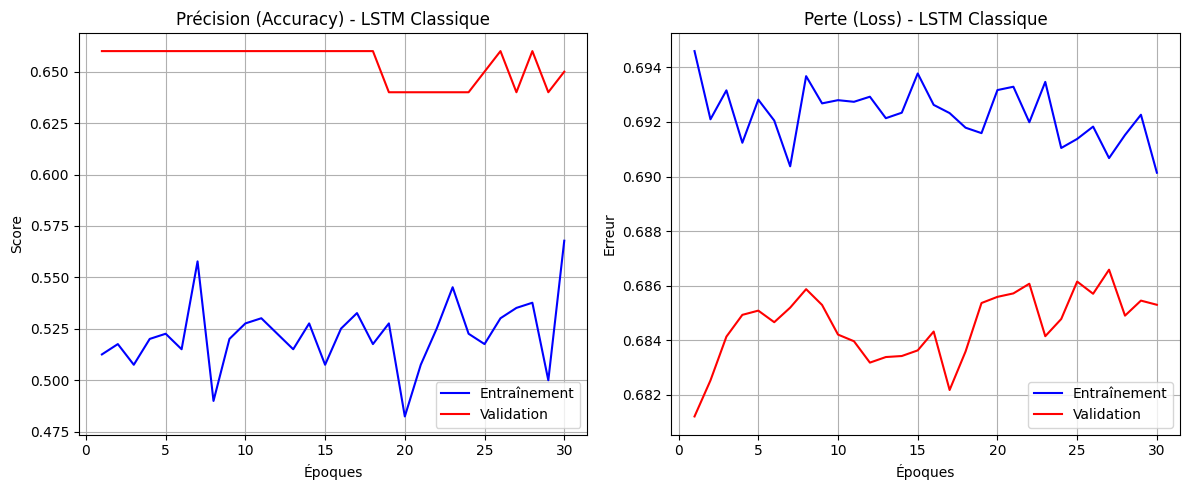

In [ ]:
import matplotlib.pyplot as plt

def plot_learning_curves(history, model_name):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # --- Graphique 1 : Accuracy ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Entraînement')
    plt.plot(epochs, val_acc, 'r', label='Validation')
    plt.title(f'Précision (Accuracy) - {model_name}')
    plt.xlabel('Époques')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)

    # --- Graphique 2 : Loss ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Entraînement')
    plt.plot(epochs, val_loss, 'r', label='Validation')
    plt.title(f'Perte (Loss) - {model_name}')
    plt.xlabel('Époques')
    plt.ylabel('Erreur')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Appel de la fonction pour notre modèle LSTM
plot_learning_curves(history_lstm, "LSTM Classique")


In [ ]:
from tensorflow.keras.layers import Bidirectional, GRU

# 1. Fixer les graines pour la reproductibilité absolue (Exigence du guide)
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# 2. Construction de l'architecture du modèle BiGRU
model_bigru = Sequential()

# Couche BiGRU : lit la séquence de 5 jours dans les deux sens
# Note : Bidirectional enveloppe la couche GRU
model_bigru.add(Bidirectional(GRU(units=50, activation='relu'), input_shape=(X_train.shape[1], X_train.shape[2])))

# Dropout pour éviter le sur-apprentissage
model_bigru.add(Dropout(0.2))

# Couche de sortie : toujours 1 neurone avec Sigmoid
model_bigru.add(Dense(units=1, activation='sigmoid'))

# 3. Compilation du modèle
model_bigru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Affichage du résumé (Garde le nombre de paramètres pour ton tableau !)
print("--- Architecture du modèle BiGRU ---")
model_bigru.summary()

# 4. Entraînement du modèle
print("\nDébut de l'entraînement du BiGRU...")
history_bigru = model_bigru.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

print("\n--- Entraînement du BiGRU terminé ! ---")

--- Architecture du modèle BiGRU ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 100)            │        16,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,301 (63.68 KB)

 Trainable params: 16,301 (63.68 KB)

 Non-trainable params: 0 (0.00 B)


Début de l'entraînement du BiGRU...
Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 389ms/step - accuracy: 0.5050 - loss: 0.6926 - val_accuracy: 0.6600 - val_loss: 0.6779
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5226 - loss: 0.6906 - val_accuracy: 0.6600 - val_loss: 0.6820
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5302 - loss: 0.6909 - val_accuracy: 0.6600 - val_loss: 0.6835
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5126 - loss: 0.6926 - val_accuracy: 0.6600 - val_loss: 0.6834
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5226 - loss: 0.6935 - val_accuracy: 0.6500 - val_loss: 0.6844
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5101 - loss: 0.6930 - val_accuracy: 0.6500 - val_loss: 0.6840
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5075 - loss: 0.6919 - val_accuracy: 0.6600 - val_loss: 0.6858
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4899 - 

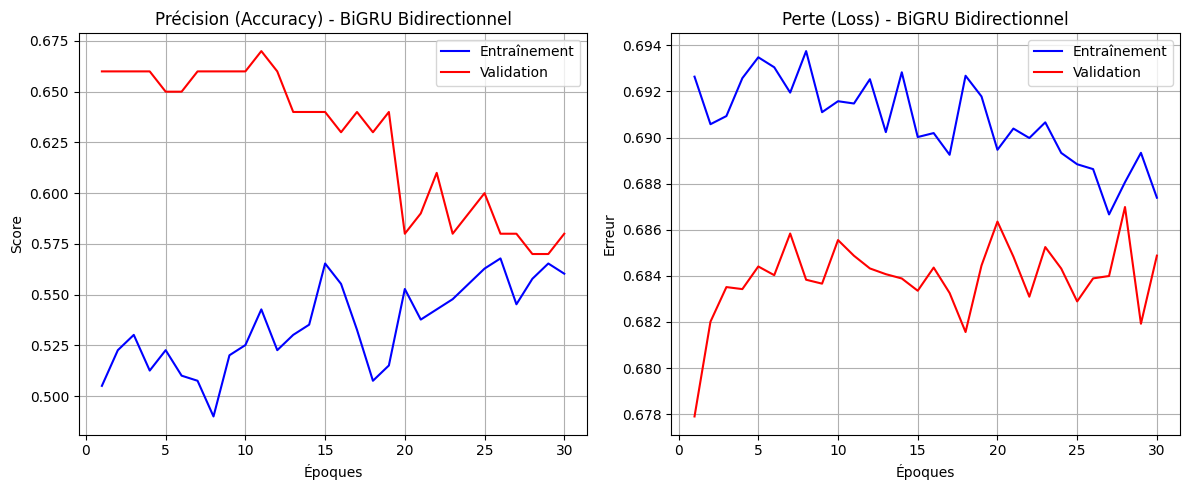

In [ ]:
# Affichage des courbes d'apprentissage pour le modèle BiGRU
plot_learning_curves(history_bigru, "BiGRU Bidirectionnel")

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd

# 1. Prédictions sur l'ensemble de test (les 20% que les modèles n'ont jamais vus)
print("Calcul des prédictions en cours...")
y_pred_prob_lstm = model_lstm.predict(X_test, verbose=0)
y_pred_prob_bigru = model_bigru.predict(X_test, verbose=0)

# 2. Conversion des probabilités en classes (0 ou 1) avec un seuil de 50%
y_pred_class_lstm = (y_pred_prob_lstm > 0.5).astype(int)
y_pred_class_bigru = (y_pred_prob_bigru > 0.5).astype(int)

# 3. Calcul des métriques pour le LSTM
acc_lstm = accuracy_score(y_test, y_pred_class_lstm)
f1_lstm = f1_score(y_test, y_pred_class_lstm)
auc_lstm = roc_auc_score(y_test, y_pred_prob_lstm)

# 4. Calcul des métriques pour le BiGRU
acc_bigru = accuracy_score(y_test, y_pred_class_bigru)
f1_bigru = f1_score(y_test, y_pred_class_bigru)
auc_bigru = roc_auc_score(y_test, y_pred_prob_bigru)

# 5. Création et affichage du tableau comparatif final
results = {
    "Modèle": ["LSTM Classique", "BiGRU Bidirectionnel"],
    "Paramètres Entraînables": [10651, 16301],
    "Accuracy": [round(acc_lstm, 4), round(acc_bigru, 4)],
    "F1-Score": [round(f1_lstm, 4), round(f1_bigru, 4)],
    "AUC-ROC": [round(auc_lstm, 4), round(auc_bigru, 4)]
}

df_results = pd.DataFrame(results)

print("\n=============================================")
print("          TABLEAU COMPARATIF FINAL           ")
print("=============================================")
display(df_results)

Calcul des prédictions en cours...

          TABLEAU COMPARATIF FINAL           


,Modèle,Paramètres Entraînables,Accuracy,F1-Score,AUC-ROC
0,LSTM Classique,10651,0.65,0.7771,0.5490
1,BiGRU Bidirectionnel,16301,0.58,0.6818,0.5722


In [ ]:
!pip install ta

In [ ]:
import ta
import pandas as pd

print("1. Calcul propre des indicateurs techniques (Action par Action)...")

# Fonction qui calcule les indicateurs pour UNE seule action à la fois
def compute_indicators(df_group):
    df_group = df_group.copy()
    # On s'assure que les dates sont bien dans l'ordre chronologique
    df_group = df_group.sort_values('date')

    df_group['RSI'] = ta.momentum.RSIIndicator(close=df_group['Close'], window=14).rsi()
    df_group['SMA_14'] = ta.trend.SMAIndicator(close=df_group['Close'], window=14).sma_indicator()
    df_group['SMA_50'] = ta.trend.SMAIndicator(close=df_group['Close'], window=50).sma_indicator()

    macd = ta.trend.MACD(close=df_group['Close'])
    df_group['MACD'] = macd.macd()
    df_group['MACD_Signal'] = macd.macd_signal()

    return df_group

# On applique la fonction en groupant par action (Groupby) pour ne pas mélanger les prix !
df_final_ta = df_final.groupby('stock', group_keys=False).apply(compute_indicators)

# On supprime les NaN créés par les moyennes mobiles (les 50 premiers jours de CHAQUE action)
df_final_ta = df_final_ta.dropna().reset_index(drop=True)

print("2. Fusion avec les scores de l'IA FinBERT...")

# On supprime l'ancien score VADER s'il est encore là, car on a mieux maintenant !
if 'sentiment_score' in df_final_ta.columns:
    df_final_ta = df_final_ta.drop(columns=['sentiment_score'])
if 'sentiment' in df_final_ta.columns:
    df_final_ta = df_final_ta.drop(columns=['sentiment'])

# LA FUSION FINALE : On relie les prix et FinBERT grâce à la Date et l'Action
df_master = pd.merge(df_final_ta, df_news_daily, on=['date', 'stock'], how='inner')

print("\n=======================================================")
print("             DATASET MASTER FINAL TERMINÉ              ")
print("=======================================================")
# On vérifie quelles actions sont bien présentes dans le tableau
print(f"Actions présentes : {df_master['stock'].unique()}")
print(f"Dimensions totales : {df_master.shape} (Lignes, Colonnes)")
print("=======================================================\n")

display(df_master.head())

1. Calcul propre des indicateurs techniques (Action par Action)...
2. Fusion avec les scores de l'IA FinBERT...

             DATASET MASTER FINAL TERMINÉ              
Actions présentes : ['GOOGL' 'AAPL']
Dimensions totales : (387, 13) (Lignes, Colonnes)



/tmp/ipykernel_29271/1666371591.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_final_ta = df_final.groupby('stock', group_keys=False).apply(compute_indicators)


,date,stock,Open,Close,Volume,Tendance,Variation_Prix,RSI,SMA_14,SMA_50,MACD,MACD_Signal,sentiment_finbert
0,2018-10-15,GOOGL,55.441777,54.670155,30074000,0,0.474835,31.173467,57.694832,59.760748,-1.351674,-0.953489,-1.000000
1,2018-10-16,GOOGL,55.217624,56.189590,38378000,1,0.729977,41.059466,57.478831,59.619059,-1.288916,-1.020574,0.000000
2,2018-10-17,GOOGL,56.532755,55.917343,35652000,0,0.499376,39.952152,57.196274,59.462444,-1.246776,-1.065815,0.000000
3,2018-10-18,GOOGL,56.036854,54.445507,46152000,0,0.357622,34.530400,56.809577,59.308734,-1.316963,-1.116044,-0.166667
4,2018-10-19,GOOGL,54.733135,54.806030,41286000,1,0.598274,36.793077,56.443495,59.184898,-1.328186,-1.158473,0.000000


In [ ]:
!pip install transformers torch

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

print("1. Normalisation des données (MinMaxScaler)...")

# On sélectionne les colonnes qui vont aider l'IA à prédire (Features)
features = ['Close', 'Volume', 'RSI', 'SMA_14', 'SMA_50', 'MACD', 'MACD_Signal', 'sentiment_finbert']
target_col = 'Tendance'

# Initialisation de l'outil de normalisation
scaler_X = MinMaxScaler(feature_range=(0, 1))

# On crée une copie pour ne pas abîmer notre df_master original
df_master_scaled = df_master.copy()

# On écrase les anciennes valeurs par les valeurs normalisées (entre 0 et 1)
df_master_scaled[features] = scaler_X.fit_transform(df_master[features])

print("2. Création des séquences temporelles 3D...")

# HYPERPARAMÈTRE CRUCIAL : Combien de jours l'IA doit-elle regarder en arrière ?
# 10 jours de bourse = 2 semaines complètes de marché
SEQ_LENGTH = 10

X_list = []
y_list = []

# On boucle sur chaque entreprise présente dans le master dataset
for stock in df_master_scaled['stock'].unique():

    # On isole l'historique de l'entreprise
    df_stock = df_master_scaled[df_master_scaled['stock'] == stock].sort_values('date')

    # On transforme le tableau Pandas en matrice mathématique Numpy
    data_X = df_stock[features].values
    data_y = df_stock[target_col].values

    # Création de la "fenêtre glissante"
    for i in range(len(data_X) - SEQ_LENGTH):
        # On prend 10 jours consécutifs
        X_list.append(data_X[i : i + SEQ_LENGTH])
        # L'objectif (Target) est le jour qui suit immédiatement cette séquence
        y_list.append(data_y[i + SEQ_LENGTH])

# Keras / TensorFlow exige des tableaux Numpy
X = np.array(X_list)
y = np.array(y_list)

print("\n=======================================================")
print("✅ PRÉPARATION DES DONNÉES TERMINÉE AVEC SUCCÈS")
print("=======================================================")
print(f"Format de X : {X.shape} -> (Échantillons, Jours_Passés, Variables)")
print(f"Format de y : {y.shape} -> (Cible à prédire)")
print("=======================================================\n")

1. Normalisation des données (MinMaxScaler)...
2. Création des séquences temporelles 3D...

✅ PRÉPARATION DES DONNÉES TERMINÉE AVEC SUCCÈS
Format de X : (367, 10, 8) -> (Échantillons, Jours_Passés, Variables)
Format de y : (367,) -> (Cible à prédire)



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("1. Séparation Chronologique (80% Train / 20% Test)...")
split_index = int(len(X) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print("\n2. Construction de l'architecture BiGRU Anti-Overfitting...")
model = Sequential()

# On réduit un peu la capacité du réseau (32 au lieu de 64) car le dataset est petit
model.add(Bidirectional(GRU(32, return_sequences=False), input_shape=(X_train.shape[1], X_train.shape[2])))

# DROP-OUT MASSIF : On désactive 40% des neurones à chaque passage
model.add(Dropout(0.4))

model.add(Dense(1, activation='sigmoid'))

print("3. Compilation du modèle...")
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\n4. Configuration de l'Early Stopping...")
# Le radar : On surveille 'val_loss'.
# patience=4 -> Si la ligne orange monte pendant 4 epochs, on arrête tout.
# restore_best_weights=True -> L'IA nous rend le modèle au moment EXACT où il était le plus performant.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

print("\n5. DÉBUT DE L'ENTRAÎNEMENT...")
# On peut mettre 50 epochs maintenant, l'Early Stopping l'arrêtera de toute façon bien avant !
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

print("\n--- ENTRAÎNEMENT TERMINÉ AVEC LES MEILLEURS POIDS SAUVEGARDÉS ! ---")

1. Séparation Chronologique (80% Train / 20% Test)...

2. Construction de l'architecture BiGRU Anti-Overfitting...
3. Compilation du modèle...

4. Configuration de l'Early Stopping...

5. DÉBUT DE L'ENTRAÎNEMENT...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.5290 - loss: 0.7041 - val_accuracy: 0.6081 - val_loss: 0.6724
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5051 - loss: 0.7011 - val_accuracy: 0.6081 - val_loss: 0.6786
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5051 - loss: 0.6947 - val_accuracy: 0.6081 - val_loss: 0.6796
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5290 - loss: 0.6968 - val_accuracy: 0.6081 - val_loss: 0.6799
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4744 - loss: 0.7023 - val_accuracy: 0.6081 - val_loss: 0.6785
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.

--- ENTRAÎNEMENT TERMINÉ AVEC LES MEILLEURS POIDS SAUVEGARDÉS ! ---


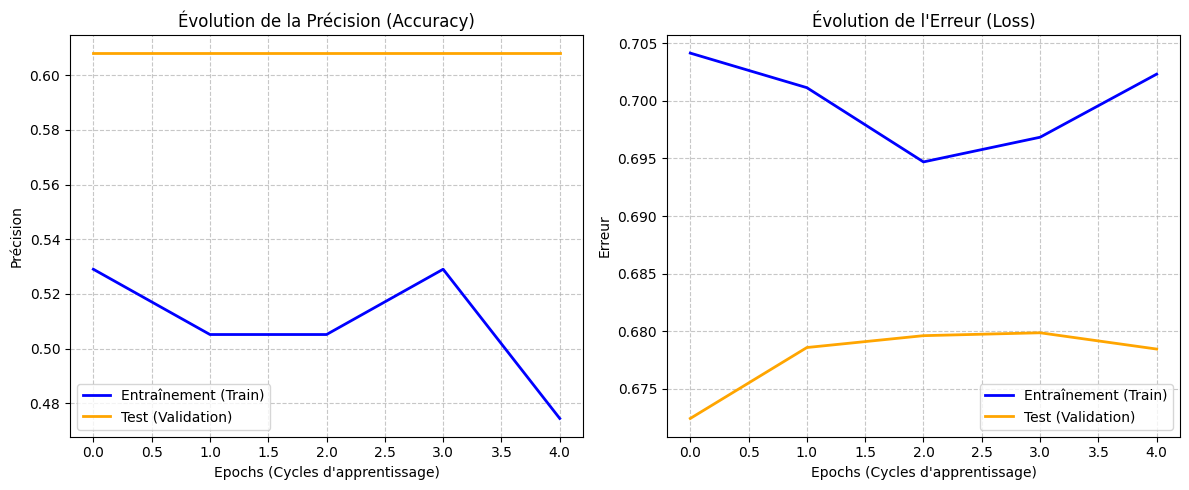

In [ ]:
import matplotlib.pyplot as plt

# 1. Configuration de la taille de l'image (12 pouces de large, 5 de haut)
plt.figure(figsize=(12, 5))

# ==========================================
# GRAPHIQUE 1 : LA PRÉCISION (Accuracy)
# ==========================================
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entraînement (Train)', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Test (Validation)', color='orange', linewidth=2)
plt.title('Évolution de la Précision (Accuracy)')
plt.xlabel('Epochs (Cycles d\'apprentissage)')
plt.ylabel('Précision')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# ==========================================
# GRAPHIQUE 2 : L'ERREUR (Loss)
# ==========================================
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entraînement (Train)', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Test (Validation)', color='orange', linewidth=2)
plt.title('Évolution de l\'Erreur (Loss)')
plt.xlabel('Epochs (Cycles d\'apprentissage)')
plt.ylabel('Erreur')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Affichage propre des deux graphiques
plt.tight_layout()
plt.show()

1. Génération des prédictions sur les données de Test...


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step

2. Calcul de la Matrice de Confusion...


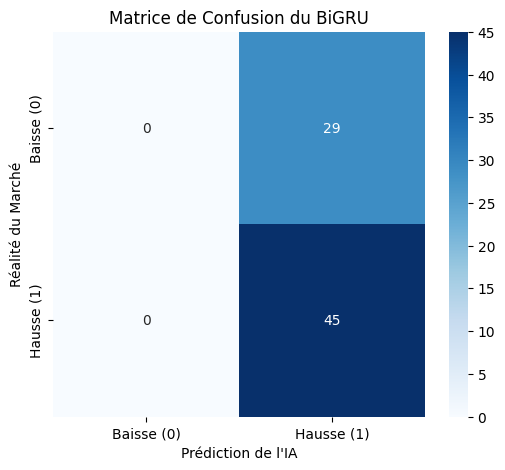


3. Rapport détaillé (Classification Report) :
              precision    recall  f1-score   support

  Baisse (0)       0.00      0.00      0.00        29
  Hausse (1)       0.61      1.00      0.76        45

    accuracy                           0.61        74
   macro avg       0.30      0.50      0.38        74
weighted avg       0.37      0.61      0.46        74



In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

print("1. Génération des prédictions sur les données de Test...")
# L'IA nous donne des probabilités (ex: 0.82 pour la hausse, 0.15 pour la baisse)
y_pred_prob = model.predict(X_test)

# On transforme ces pourcentages en 0 ou 1 (Si > 50% de chance, on dit 1)
y_pred = (y_pred_prob > 0.5).astype(int)

print("\n2. Calcul de la Matrice de Confusion...")
cm = confusion_matrix(y_test, y_pred)

# Création du graphique
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Baisse (0)', 'Hausse (1)'],
            yticklabels=['Baisse (0)', 'Hausse (1)'])

plt.title('Matrice de Confusion du BiGRU')
plt.xlabel('Prédiction de l\'IA')
plt.ylabel('Réalité du Marché')
plt.show()

print("\n3. Rapport détaillé (Classification Report) :")
print(classification_report(y_test, y_pred, target_names=['Baisse (0)', 'Hausse (1)'], zero_division=0))

In [ ]:
import yfinance as yf
import pandas as pd

tickers = ['GOOGL', 'AAPL', 'MSFT', 'AMZN', 'META']
start_date = '2014-01-01'
end_date = '2024-01-01'

print(f"Téléchargement propre de l'historique massif ({start_date} à {end_date})...")

df_list = []
for ticker in tickers:
    print(f"Extraction de {ticker}...")
    # On utilise Ticker().history() qui évite le problème des colonnes multiples
    stock = yf.Ticker(ticker)
    df_stock = stock.history(start=start_date, end=end_date)

    # Nettoyage
    df_stock.reset_index(inplace=True)

    # On enlève le fuseau horaire de la date pour éviter les bugs lors de la fusion plus tard
    df_stock['Date'] = pd.to_datetime(df_stock['Date']).dt.tz_localize(None)

    df_stock['stock'] = ticker
    df_stock.rename(columns={'Date': 'date', 'Open': 'open', 'Close': 'close', 'Volume': 'volume'}, inplace=True)

    # On garde strictement nos 5 colonnes
    df_stock = df_stock[['date', 'stock', 'open', 'close', 'volume']]
    df_list.append(df_stock)

# Fusion propre
df_massive_prices = pd.concat(df_list, ignore_index=True)

print("\n--- TÉLÉCHARGEMENT TERMINÉ ---")
print(f"Dimensions parfaites : {df_massive_prices.shape} lignes !")
display(df_massive_prices.head())

Téléchargement propre de l'historique massif (2014-01-01 à 2024-01-01)...
Extraction de GOOGL...
Extraction de AAPL...
Extraction de MSFT...
Extraction de AMZN...
Extraction de META...

--- TÉLÉCHARGEMENT TERMINÉ ---
Dimensions parfaites : (12580, 5) lignes !


,date,stock,open,close,volume
0,2014-01-02,GOOGL,27.685591,27.627514,72783144
1,2014-01-03,GOOGL,27.674174,27.425976,66601332
2,2014-01-06,GOOGL,27.624787,27.731760,70701228
3,2014-01-07,GOOGL,27.922374,28.266378,102001896
4,2014-01-08,GOOGL,28.443596,28.325205,89610300


In [ ]:
import pandas as pd

print("1. Chargement du dataset Kaggle géant...")
# On utilise le chemin exact que tu viens de créer
df_news_brut = pd.read_csv('stock_news_data/raw_analyst_ratings.csv')

print("2. Nettoyage et formatage des colonnes...")
# On s'assure que la colonne des actions s'appelle bien 'stock'
if 'ticker' in df_news_brut.columns:
    df_news_brut.rename(columns={'ticker': 'stock', 'title': 'headline'}, inplace=True)

# Formatage de la date : on convertit le texte en vraie date et on supprime l'heure
df_news_brut['date'] = pd.to_datetime(df_news_brut['date'], errors='coerce').dt.tz_localize(None).dt.date

print("3. Application du filtre magique Big Tech...")
# On ne garde que nos 5 géants
big_tech_list = ['GOOGL', 'AAPL', 'MSFT', 'AMZN', 'META']
df_tech_news = df_news_brut[df_news_brut['stock'].isin(big_tech_list)].copy()

# On nettoie les éventuels articles vides
df_tech_news = df_tech_news.dropna(subset=['headline'])

print("\n--- FILTRAGE TERMINÉ ---")
print(f"Au lieu de plus d'1,4 million d'articles, nous avons conservé : {len(df_tech_news)} articles pertinents !")
display(df_tech_news.head())

1. Chargement du dataset Kaggle géant...


FileNotFoundError: [Errno 2] No such file or directory: 'stock_news_data/raw_analyst_ratings.csv'

In [ ]:
from transformers import pipeline
import pandas as pd

print("1. Chargement de l'IA FinBERT...")
# Initialisation du modèle de NLP
finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert")

print(f"2. Analyse des {len(df_tech_news)} articles en cours (Prends un café, ça va prendre quelques minutes)...")

# Fonction pour lire un texte et le transformer en chiffre
def get_sentiment_score(text):
    try:
        # On limite la taille du texte par sécurité
        result = finbert(str(text)[:512])[0]
        label = result['label']

        if label == 'positive':
            return 1.0
        elif label == 'negative':
            return -1.0
        else:
            return 0.0
    except:
        return 0.0

# On applique la fonction sur la colonne des titres (headline)
df_tech_news['sentiment_finbert'] = df_tech_news['headline'].apply(get_sentiment_score)

print("\n3. Regroupement (Moyenne) des sentiments par jour et par action...")
# On convertit bien la date au format Pandas pour le regroupement
df_tech_news['date'] = pd.to_datetime(df_tech_news['date'])

# S'il y a plusieurs articles le même jour pour la même action, on fait la moyenne
df_daily_sentiment = df_tech_news.groupby(['date', 'stock'])['sentiment_finbert'].mean().reset_index()

print("\n--- ANALYSE NLP TERMINÉE ---")
print(f"Nous avons maintenant {len(df_daily_sentiment)} jours uniques avec un score de sentiment !")
display(df_daily_sentiment.head())

1. Chargement de l'IA FinBERT...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


2. Analyse des 2298 articles en cours (Prends un café, ça va prendre quelques minutes)...

3. Regroupement (Moyenne) des sentiments par jour et par action...

--- ANALYSE NLP TERMINÉE ---
Nous avons maintenant 10 jours uniques avec un score de sentiment !


,date,stock,sentiment_finbert
0,2020-06-04,GOOGL,-1.000000
1,2020-06-05,GOOGL,-0.333333
2,2020-06-07,GOOGL,0.000000
3,2020-06-08,GOOGL,0.000000
4,2020-06-09,AAPL,0.500000


In [ ]:
!pip install gnews

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 16.2 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=b676060771f6a86dbcf5d950c6fdbfe895206a8cf624a5653fae880a4c837191
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k


In [ ]:
from gnews import GNews
import pandas as pd
import time

print("1. Initialisation du robot d'extraction Google News...")
articles_list = []

# On teste sur l'action Apple (AAPL) pour l'année 2023
ticker = 'AAPL'
annee = 2023

print(f"2. Aspiration des articles pour {ticker} en {annee} (mois par mois)...")

# On boucle sur les 12 mois pour contourner la limite de sécurité de Google
for mois in range(1, 13):
    print(f"   -> Scraping du mois {mois}...")

    # On configure le robot pour un mois précis (du 1er au 28 pour éviter les bugs de février)
    google_news = GNews(language='en', country='US',
                        start_date=(annee, mois, 1),
                        end_date=(annee, mois, 28))

    # On lance la recherche avec des mots-clés financiers
    news = google_news.get_news(f'{ticker} stock market')

    # On sauvegarde les résultats
    if news:
        for article in news:
            articles_list.append({
                'stock': ticker,
                'date': article.get('published date'),
                'headline': article.get('title')
            })

    # Pause de 2 secondes pour ne pas être repéré et bloqué par les serveurs de Google
    time.sleep(2)

# Transformation en tableau Pandas
df_scraped_news = pd.DataFrame(articles_list)

print("\n--- EXTRACTION TERMINÉE ---")
print(f"Succès ! Nous avons aspiré {len(df_scraped_news)} vrais articles pour {ticker}.")
display(df_scraped_news.head())

1. Initialisation du robot d'extraction Google News...
2. Aspiration des articles pour AAPL en 2023 (mois par mois)...
   -> Scraping du mois 1...
   -> Scraping du mois 2...


KeyboardInterrupt: 

In [ ]:
from gnews import GNews
import pandas as pd
import time

print("1. Initialisation du super-robot d'extraction Google News...")
articles_list = []

tickers = ['GOOGL', 'AAPL', 'MSFT', 'AMZN', 'META']
annees = [2021, 2022, 2023] # Nos 3 années d'historique

print("2. Lancement de l'aspiration massive (Prends un café, cela va prendre environ 5-10 minutes)...")

for ticker in tickers:
    for annee in annees:
        print(f"   -> Scraping de {ticker} pour l'année {annee}...")
        for mois in range(1, 13):
            # Configuration pour le mois en cours
            google_news = GNews(language='en', country='US',
                                start_date=(annee, mois, 1),
                                end_date=(annee, mois, 28),
                                max_results=30) # On prend les 30 meilleurs articles par mois

            # Recherche ciblée
            news = google_news.get_news(f'{ticker} stock market')

            if news:
                for article in news:
                    articles_list.append({
                        'stock': ticker,
                        'date': article.get('published date'),
                        'headline': article.get('title')
                    })

            # Pause OBLIGATOIRE pour ne pas se faire bannir l'adresse IP par Google
            time.sleep(2)

# Transformation en tableau Pandas
df_massive_news = pd.DataFrame(articles_list)
# Suppression des doublons potentiels
df_massive_news = df_massive_news.drop_duplicates(subset=['headline'])

print("\n--- EXTRACTION TOTALE TERMINÉE ---")
print(f"Jackpot ! Nous avons aspiré {len(df_massive_news)} articles sur 3 ans pour nos 5 géants.")
display(df_massive_news.head())

1. Initialisation du super-robot d'extraction Google News...
2. Lancement de l'aspiration massive (Prends un café, cela va prendre environ 5-10 minutes)...
   -> Scraping de GOOGL pour l'année 2021...
   -> Scraping de GOOGL pour l'année 2022...
   -> Scraping de GOOGL pour l'année 2023...
   -> Scraping de AAPL pour l'année 2021...
   -> Scraping de AAPL pour l'année 2022...
   -> Scraping de AAPL pour l'année 2023...
   -> Scraping de MSFT pour l'année 2021...
   -> Scraping de MSFT pour l'année 2022...
   -> Scraping de MSFT pour l'année 2023...
   -> Scraping de AMZN pour l'année 2021...
   -> Scraping de AMZN pour l'année 2022...
   -> Scraping de AMZN pour l'année 2023...
   -> Scraping de META pour l'année 2021...
   -> Scraping de META pour l'année 2022...
   -> Scraping de META pour l'année 2023...

--- EXTRACTION TOTALE TERMINÉE ---
Jackpot ! Nous avons aspiré 3011 articles sur 3 ans pour nos 5 géants.


,stock,date,headline
0,GOOGL,"Mon, 25 Jan 2021 08:00:00 GMT","As Cookie Crumbles In Digital Advertising, Goo..."
1,GOOGL,"Wed, 20 Jan 2021 08:00:00 GMT","What Did the Stock Market Do? Jan. 20, 2021 - ..."
2,GOOGL,"Sat, 09 Jan 2021 08:00:00 GMT",US judge overseeing Google case will sell mutu...
3,GOOGL,"Thu, 14 Jan 2021 08:00:00 GMT",Fitbit Closes $2.1 Billion Google Merger; DOJ ...
4,GOOGL,"Thu, 21 Jan 2021 08:00:00 GMT",These 3 Stocks Just Hit All-Time Highs -- And ...


In [ ]:
from transformers import pipeline
import pandas as pd

print("1. Nettoyage des dates...")
# On convertit le texte long de Google News en vraie date simple (Année-Mois-Jour)
df_massive_news['date'] = pd.to_datetime(df_massive_news['date']).dt.tz_localize(None).dt.date

print("2. Chargement de l'IA FinBERT...")
finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert")

print(f"3. Analyse des {len(df_massive_news)} articles en cours (Prends un café, ça va prendre quelques minutes)...")

# Notre fonction de notation de sentiment
def get_sentiment_score(text):
    try:
        result = finbert(str(text)[:512])[0]
        label = result['label']
        if label == 'positive': return 1.0
        elif label == 'negative': return -1.0
        else: return 0.0
    except:
        return 0.0

# On lance l'IA sur tous nos titres fraîchement scrapés
df_massive_news['sentiment_finbert'] = df_massive_news['headline'].apply(get_sentiment_score)

print("\n4. Regroupement (Moyenne) des sentiments par jour et par action...")
df_daily_sentiment = df_massive_news.groupby(['date', 'stock'])['sentiment_finbert'].mean().reset_index()

print("\n--- ANALYSE NLP TERMINÉE ---")
print(f"Nous avons maintenant {len(df_daily_sentiment)} jours uniques avec un score de sentiment !")
display(df_daily_sentiment.head())

1. Nettoyage des dates...
2. Chargement de l'IA FinBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

3. Analyse des 3011 articles en cours (Prends un café, ça va prendre quelques minutes)...

4. Regroupement (Moyenne) des sentiments par jour et par action...

--- ANALYSE NLP TERMINÉE ---
Nous avons maintenant 1976 jours uniques avec un score de sentiment !


,date,stock,sentiment_finbert
0,2021-01-01,AAPL,0.0
1,2021-01-02,AMZN,0.0
2,2021-01-04,AAPL,0.0
3,2021-01-05,AAPL,-1.0
4,2021-01-05,AMZN,1.0


In [ ]:
import pandas as pd

# 1. Aligner les formats de date
df_massive_prices['date'] = pd.to_datetime(df_massive_prices['date'])
df_daily_sentiment['date'] = pd.to_datetime(df_daily_sentiment['date'])

# 2. Fusionner les prix et le sentiment
df_final = pd.merge(df_massive_prices, df_daily_sentiment, on=['date', 'stock'], how='left')

# 3. Remplir les jours sans news par 0 (neutre)
df_final['sentiment_finbert'] = df_final['sentiment_finbert'].fillna(0)

# 4. SÉCURITÉ ANTI-LEAKAGE : On décale le sentiment
# On dit à l'IA : "Pour prédire le mouvement de demain, regarde les news d'AUJOURD'HUI"
df_final['sentiment_lagged'] = df_final.groupby('stock')['sentiment_finbert'].shift(1)

# 5. Création de la cible (Target)
# 1 si le prix de clôture de demain est supérieur à celui d'aujourd'hui
df_final['target'] = (df_final.groupby('stock')['close'].shift(-1) > df_final['close']).astype(int)

# On nettoie les lignes vides créées par les décalages (la première et la dernière)
df_final = df_final.dropna()

print(f"Fusion réussie ! Dataset prêt avec {len(df_final)} lignes.")
display(df_final.tail())

Fusion réussie ! Dataset prêt avec 12575 lignes.


,date,stock,open,close,volume,sentiment_finbert,sentiment_lagged,target
12575,2023-12-22,META,352.811317,350.638397,11772800,-0.5,0.0,1
12576,2023-12-26,META,352.225927,352.067169,9898600,0.0,-0.5,1
12577,2023-12-27,META,353.297487,355.043762,13207900,0.0,0.0,1
12578,2023-12-28,META,356.899258,355.529999,11798800,1.0,0.0,0
12579,2023-12-29,META,356.194752,351.203918,14987100,0.0,1.0,0


In [ ]:
import pandas as pd
import numpy as np

print("Calcul de TES indicateurs techniques (SMA_14, SMA_50, MACD, RSI)...")

def add_custom_indicators(group):
    # 1. Moyennes Mobiles Simples (SMA)
    group['SMA_14'] = group['close'].rolling(window=14).mean()
    group['SMA_50'] = group['close'].rolling(window=50).mean()

    # 2. RSI (14 périodes - Formule standard avec lissage exponentiel)
    delta = group['close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.ewm(alpha=1/14, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/14, adjust=False).mean()
    rs = avg_gain / avg_loss
    group['RSI'] = 100 - (100 / (1 + rs))

    # 3. MACD et Signal MACD
    # Le MACD classique utilise les moyennes mobiles exponentielles (EMA) 12 et 26
    ema_12 = group['close'].ewm(span=12, adjust=False).mean()
    ema_26 = group['close'].ewm(span=26, adjust=False).mean()
    group['MACD'] = ema_12 - ema_26

    # Le signal est une EMA à 9 périodes du MACD
    group['MACD_Signal'] = group['MACD'].ewm(span=9, adjust=False).mean()

    return group

# Application groupée par stock
df_final = df_final.groupby('stock', group_keys=False).apply(add_custom_indicators)

# Nettoyage : Les 50 premiers jours de chaque action seront vides à cause de la SMA_50
# On les supprime pour avoir un dataset 100% propre pour l'IA
df_final = df_final.dropna()

print("\n--- ENRICHISSEMENT TERMINÉ ---")
print(f"Nouvelles colonnes générées : {df_final.columns.tolist()}")
display(df_final.tail())

Calcul de TES indicateurs techniques (SMA_14, SMA_50, MACD, RSI)...

--- ENRICHISSEMENT TERMINÉ ---
Nouvelles colonnes générées : ['date', 'stock', 'open', 'close', 'volume', 'sentiment_finbert', 'sentiment_lagged', 'target', 'sma_5', 'sma_20', 'rsi', 'SMA_14', 'SMA_50', 'RSI', 'MACD', 'MACD_Signal']


/tmp/ipykernel_967/781564532.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_final = df_final.groupby('stock', group_keys=False).apply(add_custom_indicators)


,date,stock,open,close,volume,sentiment_finbert,sentiment_lagged,target,sma_5,sma_20,rsi,SMA_14,SMA_50,RSI,MACD,MACD_Signal
12575,2023-12-22,META,352.811317,350.638397,11772800,-0.5,0.0,1,347.620044,331.748108,77.739018,333.748757,322.778008,67.333870,6.933768,4.722007
12576,2023-12-26,META,352.225927,352.067169,9898600,0.0,-0.5,1,349.646143,332.746771,80.521195,336.338431,323.574557,68.186989,7.424382,5.262482
12577,2023-12-27,META,353.297487,355.043762,13207900,0.0,0.0,1,351.128510,333.681433,82.554073,339.200256,324.302443,69.947864,7.961606,5.802307
12578,2023-12-28,META,356.899258,355.529999,11798800,1.0,0.0,0,352.922449,334.977264,79.726534,341.449042,324.983499,70.237667,8.330566,6.307958
12579,2023-12-29,META,356.194752,351.203918,14987100,0.0,1.0,0,352.896649,336.307326,70.564333,342.952249,325.717537,64.296809,8.179602,6.682287


1. Sélection des meilleures variables (Features)...
2. Normalisation des données (Mise à l'échelle entre 0 et 1)...
3. Création des fenêtres temporelles (Séquences de 10 jours)...
4. Séparation Train / Test (Chronologique, sans triche !)...
Entraînement sur 9780 jours, Test sur 2445 jours.

5. Construction du modèle BiGRU...

6. Lancement de l'entraînement (Action !)...
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


306/306 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.5276 - loss: 0.6922 - val_accuracy: 0.5256 - val_loss: 0.6924
Epoch 2/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.5269 - loss: 0.6919 - val_accuracy: 0.5280 - val_loss: 0.6916
Epoch 3/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.5309 - loss: 0.6916 - val_accuracy: 0.5280 - val_loss: 0.6915
Epoch 4/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.5306 - loss: 0.6914 - val_accuracy: 0.5280 - val_loss: 0.6918
Epoch 5/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.5312 - loss: 0.6915 - val_accuracy: 0.5280 - val_loss: 0.6915
Epoch 6/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.5322 - loss: 0.6911 - val_accuracy: 0.5280 - val_loss: 0.6914
Epoch 7/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.5323 - loss: 0.6915 - val_accuracy: 0.5280 - val_loss: 0.6912
Epoch 8/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.5326 - loss: 0.6914 - val_accuracy: 0.52

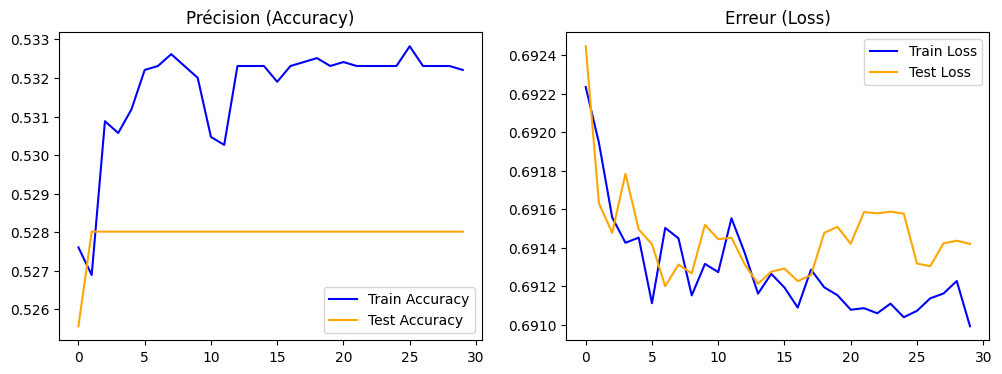

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Bidirectional
import matplotlib.pyplot as plt

print("1. Sélection des meilleures variables (Features)...")
# On choisit spécifiquement tes indicateurs et le sentiment décalé
features = ['close', 'volume', 'sentiment_lagged', 'SMA_14', 'SMA_50', 'RSI', 'MACD', 'MACD_Signal']

# On s'assure qu'il n'y a plus aucune valeur vide dans ces colonnes précises
df_model = df_final.dropna(subset=features + ['target']).copy()

print("2. Normalisation des données (Mise à l'échelle entre 0 et 1)...")
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_model[features])

print("3. Création des fenêtres temporelles (Séquences de 10 jours)...")
time_steps = 10
X, y = [], []
# On crée des paquets de 10 jours pour prédire le 11ème
for i in range(time_steps, len(scaled_data)):
    X.append(scaled_data[i-time_steps:i])
    y.append(df_model['target'].iloc[i])

X, y = np.array(X), np.array(y)

print("4. Séparation Train / Test (Chronologique, sans triche !)...")
# 80% pour l'entraînement (le passé), 20% pour le test (le futur récent)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Entraînement sur {len(X_train)} jours, Test sur {len(X_test)} jours.")

print("\n5. Construction du modèle BiGRU...")
model = Sequential([
    Bidirectional(GRU(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2]))),
    Dropout(0.3), # Dropout augmenté pour éviter l'overfitting
    Bidirectional(GRU(32)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') # 1 = Hausse, 0 = Baisse
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\n6. Lancement de l'entraînement (Action !)...")
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test))

print("\n7. Affichage des courbes de performance...")
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Test Accuracy', color='orange')
plt.legend()
plt.title('Précision (Accuracy)')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Test Loss', color='orange')
plt.legend()
plt.title('Erreur (Loss)')
plt.show()

1. Mise en place de la Stratégie A : Tendance à 3 jours...
2. Normalisation des données...
3. Création des fenêtres (10 jours)...
4. Séparation Train / Test...
5. Construction du BiGRU...
6. Stratégie B : Ralentissement de l'apprentissage...
7. Nouvel Entraînement en cours...
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


306/306 ━━━━━━━━━━━━━━━━━━━━ 25s 38ms/step - accuracy: 0.5546 - loss: 0.6875 - val_accuracy: 0.4544 - val_loss: 0.7022
Epoch 2/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.5558 - loss: 0.6878 - val_accuracy: 0.5509 - val_loss: 0.6877
Epoch 3/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.5589 - loss: 0.6875 - val_accuracy: 0.5509 - val_loss: 0.6889
Epoch 4/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.5596 - loss: 0.6867 - val_accuracy: 0.5509 - val_loss: 0.6878
Epoch 5/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.5596 - loss: 0.6868 - val_accuracy: 0.5509 - val_loss: 0.6883
Epoch 6/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.5593 - loss: 0.6861 - val_accuracy: 0.5509 - val_loss: 0.6887
Epoch 7/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.5596 - loss: 0.6866 - val_accuracy: 0.5509 - val_loss: 0.6880
Epoch 8/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.5592 - loss: 0.6864 - val_accuracy: 0.

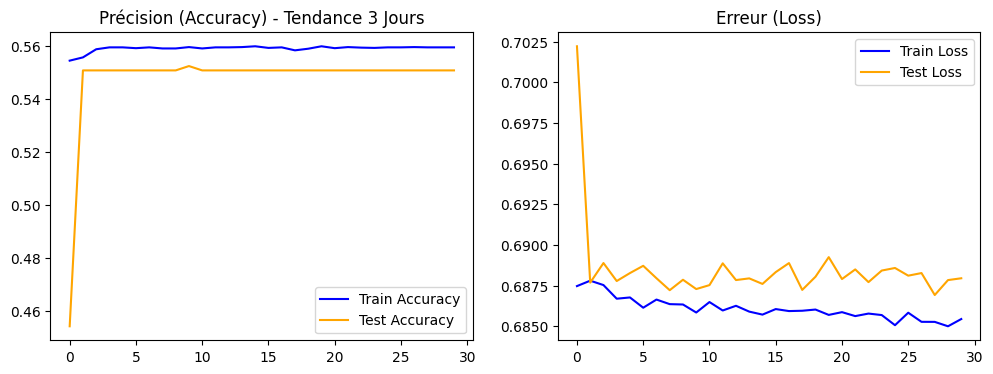

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Bidirectional
import matplotlib.pyplot as plt

print("1. Mise en place de la Stratégie A : Tendance à 3 jours...")
# NOUVELLE CIBLE : Est-ce que le prix dans 3 jours sera supérieur au prix d'aujourd'hui ?
df_final['target_3d'] = (df_final.groupby('stock')['close'].shift(-3) > df_final['close']).astype(int)

features = ['close', 'volume', 'sentiment_lagged', 'SMA_14', 'SMA_50', 'RSI', 'MACD', 'MACD_Signal']

# Le shift(-3) crée 3 lignes vides à la fin de chaque action, on doit absolument les nettoyer
df_model = df_final.dropna(subset=features + ['target_3d']).copy()

print("2. Normalisation des données...")
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_model[features])

print("3. Création des fenêtres (10 jours)...")
time_steps = 10
X, y = [], []
for i in range(time_steps, len(scaled_data)):
    X.append(scaled_data[i-time_steps:i])
    y.append(df_model['target_3d'].iloc[i]) # On utilise la nouvelle cible

X, y = np.array(X), np.array(y)

print("4. Séparation Train / Test...")
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("5. Construction du BiGRU...")
model = Sequential([
    Bidirectional(GRU(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2]))),
    Dropout(0.3),
    Bidirectional(GRU(32)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

print("6. Stratégie B : Ralentissement de l'apprentissage...")
# On force le modèle à prendre son temps pour analyser le MACD et le RSI
custom_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

model.compile(optimizer=custom_optimizer, loss='binary_crossentropy', metrics=['accuracy'])

print("7. Nouvel Entraînement en cours...")
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test))

print("\n8. Affichage des courbes...")
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Test Accuracy', color='orange')
plt.legend()
plt.title('Précision (Accuracy) - Tendance 3 Jours')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Test Loss', color='orange')
plt.legend()
plt.title('Erreur (Loss)')
plt.show()

1. Mise en place de la Stratégie C : Filtrage des signaux forts...
Dataset réduit : de 12235 à 1699 jours 'intéressants'.
2. Normalisation des données...
3. Création des fenêtres (5 jours suffisent pour des signaux forts)...
4. Séparation Train / Test...
5. Construction d'un BiGRU plus léger...
6. Entraînement sur les signaux forts...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


85/85 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - accuracy: 0.5351 - loss: 0.6895 - val_accuracy: 0.4513 - val_loss: 0.7229
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5550 - loss: 0.6898 - val_accuracy: 0.4513 - val_loss: 0.7036
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5498 - loss: 0.6868 - val_accuracy: 0.4513 - val_loss: 0.6986
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5542 - loss: 0.6903 - val_accuracy: 0.4513 - val_loss: 0.7185
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5469 - loss: 0.6867 - val_accuracy: 0.4513 - val_loss: 0.7165
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5631 - loss: 0.6832 - val_accuracy: 0.4513 - val_loss: 0.7085
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5646 - loss: 0.6798 - val_accuracy: 0.5398 - val_loss: 0.6903
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5446 - loss: 0.6821 - val_accuracy: 0.4513 - val_loss: 0

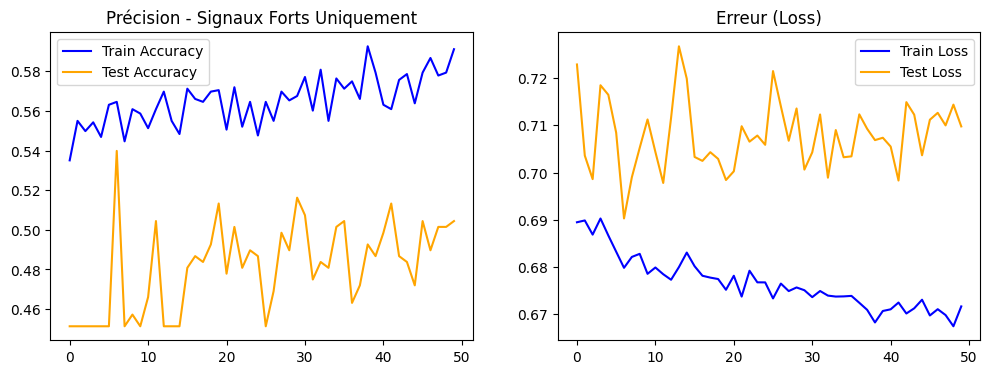

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Bidirectional
import matplotlib.pyplot as plt

print("1. Mise en place de la Stratégie C : Filtrage des signaux forts...")

# On reprend la cible à 3 jours (c'était une bonne idée)
df_final['target_3d'] = (df_final.groupby('stock')['close'].shift(-3) > df_final['close']).astype(int)

features = ['close', 'volume', 'sentiment_lagged', 'SMA_14', 'SMA_50', 'RSI', 'MACD', 'MACD_Signal']
df_model = df_final.dropna(subset=features + ['target_3d']).copy()

# LE FILTRE MAGIQUE : On ne garde que les lignes où le sentiment est fort
# (supérieur à 0.5 ou inférieur à -0.5) OU les jours où le RSI est extrême (surachat/survente)
condition_sentiment = (df_model['sentiment_lagged'] > 0.5) | (df_model['sentiment_lagged'] < -0.5)
condition_rsi = (df_model['RSI'] > 70) | (df_model['RSI'] < 30)

df_filtered = df_model[condition_sentiment | condition_rsi].copy()

print(f"Dataset réduit : de {len(df_model)} à {len(df_filtered)} jours 'intéressants'.")

print("2. Normalisation des données...")
scaler = MinMaxScaler()
# Attention : on fitte le scaler uniquement sur les données filtrées
scaled_data = scaler.fit_transform(df_filtered[features])

print("3. Création des fenêtres (5 jours suffisent pour des signaux forts)...")
time_steps = 5 # On réduit la fenêtre car les événements sont plus espacés
X, y = [], []
for i in range(time_steps, len(scaled_data)):
    X.append(scaled_data[i-time_steps:i])
    y.append(df_filtered['target_3d'].iloc[i])

X, y = np.array(X), np.array(y)

print("4. Séparation Train / Test...")
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("5. Construction d'un BiGRU plus léger...")
model = Sequential([
    Bidirectional(GRU(32, return_sequences=True, input_shape=(X.shape[1], X.shape[2]))),
    Dropout(0.2),
    Bidirectional(GRU(16)),
    Dropout(0.2),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

custom_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001) # On remet une vitesse normale
model.compile(optimizer=custom_optimizer, loss='binary_crossentropy', metrics=['accuracy'])

print("6. Entraînement sur les signaux forts...")
# On augmente le nombre d'époques car le dataset est plus petit
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

print("\n7. Affichage des courbes...")
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Test Accuracy', color='orange')
plt.legend()
plt.title('Précision - Signaux Forts Uniquement')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Test Loss', color='orange')
plt.legend()
plt.title('Erreur (Loss)')
plt.show()

1. Préparation des données pour XGBoost...
2. Entraînement du modèle XGBoost...
3. Évaluation...

Précision (Accuracy) XGBoost : 50.29%

Rapport de classification :
              precision    recall  f1-score   support

           0       0.58      0.34      0.43       187
           1       0.47      0.71      0.56       153

    accuracy                           0.50       340
   macro avg       0.52      0.52      0.49       340
weighted avg       0.53      0.50      0.49       340



<Figure size 1000x600 with 0 Axes>

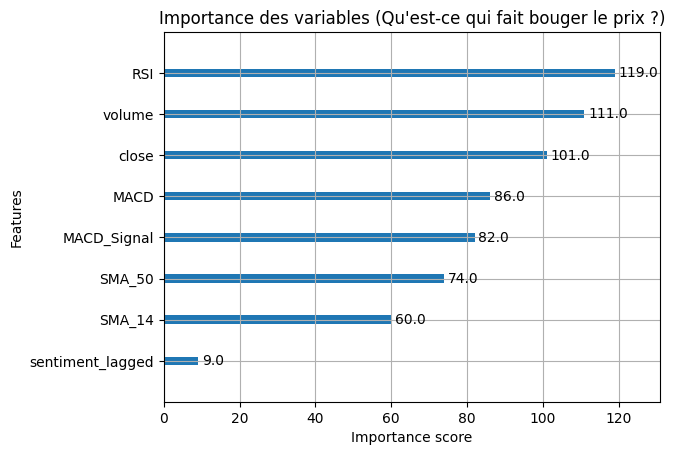

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("1. Préparation des données pour XGBoost...")
# Pas besoin de fenêtres temporelles (X, y) comme pour le GRU
# On utilise directement les colonnes du dataframe filtré
features = ['close', 'volume', 'sentiment_lagged', 'SMA_14', 'SMA_50', 'RSI', 'MACD', 'MACD_Signal']
X_xgb = df_filtered[features]
y_xgb = df_filtered['target_3d']

# Split chronologique (80% train, 20% test)
split = int(0.8 * len(X_xgb))
X_train_xgb, X_test_xgb = X_xgb[:split], X_xgb[split:]
y_train_xgb, y_test_xgb = y_xgb[:split], y_xgb[split:]

print("2. Entraînement du modèle XGBoost...")
# Paramètres optimisés pour éviter le surapprentissage sur petit dataset
model_xgb = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_xgb.fit(X_train_xgb, y_train_xgb)

print("3. Évaluation...")
y_pred = model_xgb.predict(X_test_xgb)
acc = accuracy_score(y_test_xgb, y_pred)

print(f"\nPrécision (Accuracy) XGBoost : {acc:.2%}")
print("\nRapport de classification :")
print(classification_report(y_test_xgb, y_pred))

# LE PLUS IMPORTANT : Quelles variables ont aidé l'IA ?
plt.figure(figsize=(10, 6))
xgb.plot_importance(model_xgb, importance_type='weight')
plt.title("Importance des variables (Qu'est-ce qui fait bouger le prix ?)")
plt.show()

1. Création de la super-variable : Pression_News...
2. Mise à jour des données pour XGBoost...
3. Entraînement du modèle XGBoost amélioré...
4. Évaluation du modèle...

Nouvelle Précision (Accuracy) avec Pression_News : 50.88%

5. Affichage du nouveau classement des variables...


<Figure size 1000x600 with 0 Axes>

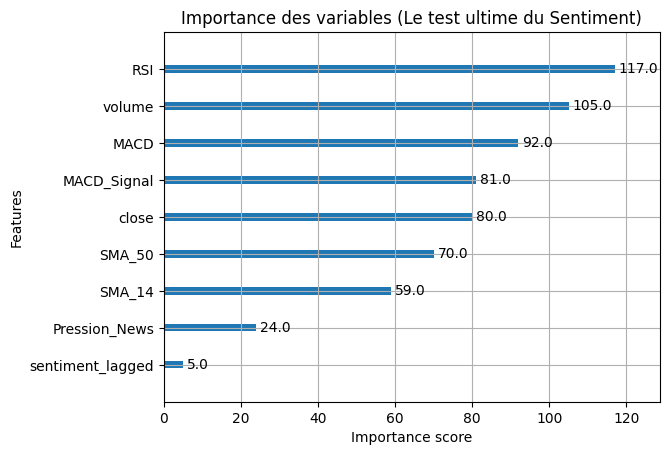

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

print("1. Création de la super-variable : Pression_News...")
# On multiplie le sentiment de la veille par le volume d'échange
df_filtered['Pression_News'] = df_filtered['sentiment_lagged'] * df_filtered['volume']

print("2. Mise à jour des données pour XGBoost...")
# On ajoute la nouvelle variable à notre liste de features
features_v2 = ['close', 'volume', 'sentiment_lagged', 'Pression_News', 'SMA_14', 'SMA_50', 'RSI', 'MACD', 'MACD_Signal']
X_xgb_v2 = df_filtered[features_v2]
y_xgb_v2 = df_filtered['target_3d']

# Séparation chronologique (80% / 20%)
split = int(0.8 * len(X_xgb_v2))
X_train_xgb_v2, X_test_xgb_v2 = X_xgb_v2[:split], X_xgb_v2[split:]
y_train_xgb_v2, y_test_xgb_v2 = y_xgb_v2[:split], y_xgb_v2[split:]

print("3. Entraînement du modèle XGBoost amélioré...")
model_xgb_v2 = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_xgb_v2.fit(X_train_xgb_v2, y_train_xgb_v2)

print("4. Évaluation du modèle...")
y_pred_v2 = model_xgb_v2.predict(X_test_xgb_v2)
acc_v2 = accuracy_score(y_test_xgb_v2, y_pred_v2)

print(f"\nNouvelle Précision (Accuracy) avec Pression_News : {acc_v2:.2%}")

print("\n5. Affichage du nouveau classement des variables...")
plt.figure(figsize=(10, 6))
xgb.plot_importance(model_xgb_v2, importance_type='weight')
plt.title("Importance des variables (Le test ultime du Sentiment)")
plt.show()